In [1]:
# Install required libraries if not installed
# !pip install imbalanced-learn scikit-learn

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder


# 🔹 Load dataset (Ensure df is preprocessed and numeric)
# df = pd.read_csv("your_processed_data.csv")
file_path = r"H:\Master Files\cleaned_data.xlsx"

# Read the Excel file
df = pd.read_excel(file_path, engine="openpyxl")
# 🔹 Convert Categorical Columns to Numeric
for col in df.columns:
    if df[col].dtype == 'object':  # If column is categorical
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])  # Convert to numbers

# 🔹 Define Features (X) and Target (y)
X = df.iloc[:, :-1].values  # Features (all columns except last)
y = df.iloc[:, -1].values   # Target (last column)

# 🔹 Split Data (Train: 80%, Test: 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Apply SMOTE to balance the dataset
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 🔹 Standardize Features (Important for KNN)
scaler = StandardScaler()
X_train_balanced = scaler.fit_transform(X_train_balanced)
X_test = scaler.transform(X_test)

# 🔹 Train KNN Model (with k=5, tune this if needed)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_balanced, y_train_balanced)

# 🔹 Predict on Test Set
y_pred = knn.predict(X_test)

# 🔹 Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"✅ KNN Accuracy: {accuracy:.4f}")
print(f"✅ KNN F1-Score: {f1:.4f}")
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred))


✅ KNN Accuracy: 0.9766
✅ KNN F1-Score: 0.9766

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       181
           1       0.99      0.97      0.98       204

    accuracy                           0.98       385
   macro avg       0.98      0.98      0.98       385
weighted avg       0.98      0.98      0.98       385



In [2]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, mean_squared_error

# 🔹 Compute Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mse = mean_squared_error(y_test, y_pred)

# 🔹 Print Results
print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall: {recall:.4f}")
print(f"✅ F1-Score: {f1:.4f}")
print(f"✅ Mean Squared Error (MSE): {mse:.4f}")

✅ Accuracy: 0.9766
✅ Precision: 0.9768
✅ Recall: 0.9766
✅ F1-Score: 0.9766
✅ Mean Squared Error (MSE): 0.0234


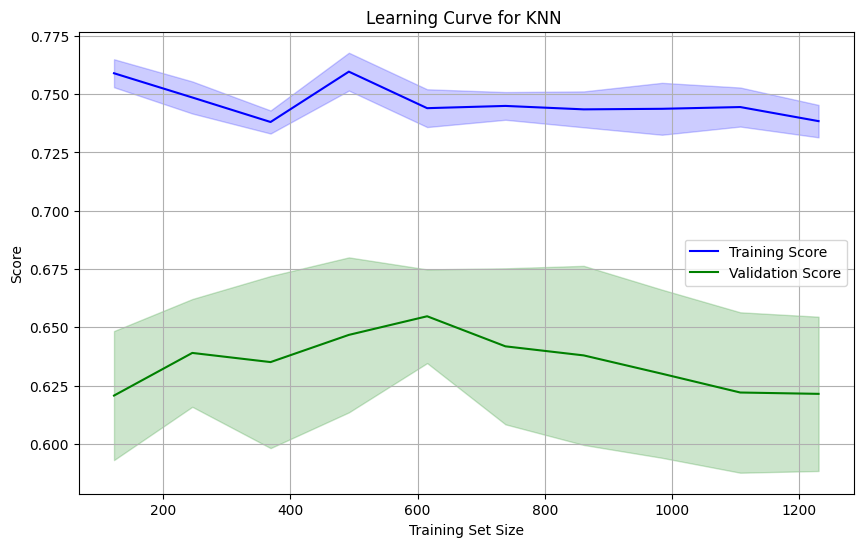

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer

# Define the scoring metric (Accuracy or F1-Score)
scorer = make_scorer(f1_score, average='weighted')

# 🔹 Generate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    knn, X_train, y_train, train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    cv=5, scoring=scorer, n_jobs=-1)

# Calculate the mean and standard deviation of training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# 🔹 Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.plot(train_sizes, val_mean, label='Validation Score', color='green')

# Plot the fill for standard deviation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='green')

# Labeling the graph
plt.title('Learning Curve for KNN ')
plt.xlabel('Training Set Size')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix:
[[178   3]
 [  6 198]]


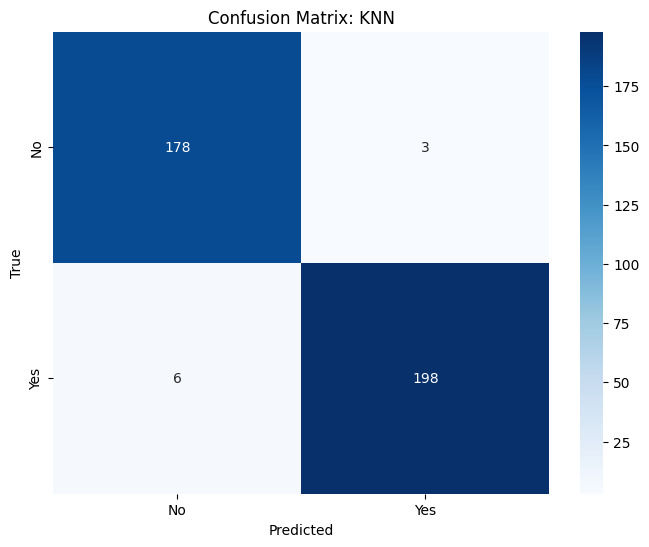

In [4]:
from sklearn.metrics import confusion_matrix

# 🔹 Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 🔹 Display the Confusion Matrix
print("Confusion Matrix:")
print(cm)
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Plot Confusion Matrix as Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix: KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

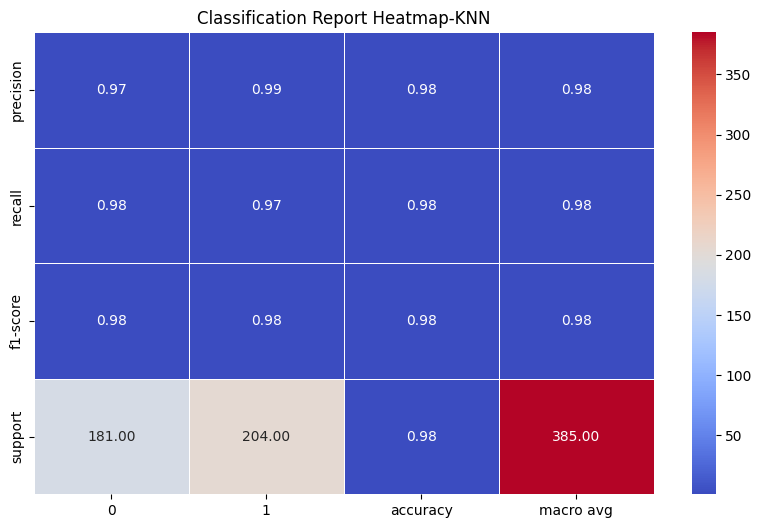

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd

# Generate the classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the dictionary to a DataFrame
report_df = pd.DataFrame(report).T

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Classification Report Heatmap-KNN')
plt.show()

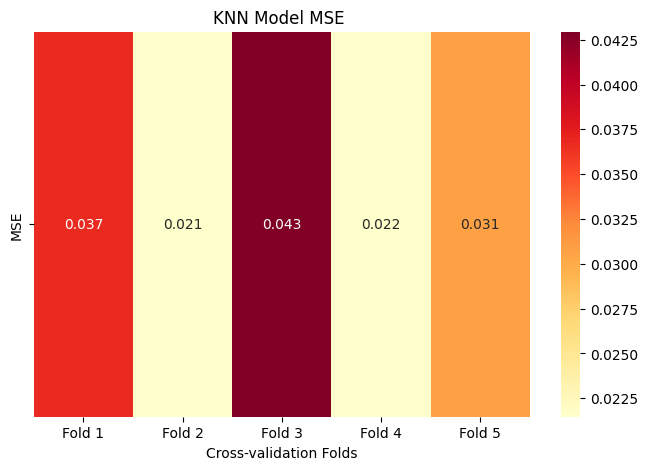

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
file_path = r"H:\Master Files\cleaned_data.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

# Preprocess: Convert categorical columns to numeric
for col in df.columns:
    if df[col].dtype == 'object':  # If column is categorical
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

# Define Features (X) and Target (y)
X = df.iloc[:, :-1].values  # Features (all columns except last)
y = df.iloc[:, -1].values   # Target (last column)

# Split Data (Train: 80%, Test: 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the dataset
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Standardize Features
scaler = StandardScaler()
X_train_balanced = scaler.fit_transform(X_train_balanced)
X_test = scaler.transform(X_test)

# Train KNN Model (with k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_balanced, y_train_balanced)

# Perform Cross-validation to get MSE values
mse_scorer = make_scorer(mean_squared_error)
cv_scores = cross_val_score(knn, X_train_balanced, y_train_balanced, cv=5, scoring=mse_scorer)

# Plotting MSE in a Single Rectangle
plt.figure(figsize=(8, 5))
sns.heatmap(cv_scores.reshape(1, -1), annot=True, cmap='YlOrRd', cbar=True, 
            xticklabels=[f'Fold {i+1}' for i in range(len(cv_scores))], 
            yticklabels=["MSE"])
plt.title('KNN Model MSE ')
plt.xlabel('Cross-validation Folds')
# plt.ylabel('MSE')
plt.show()

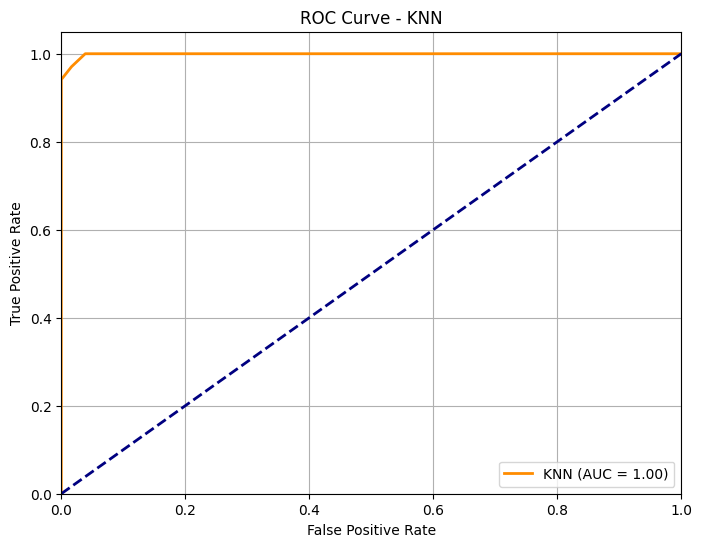

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 🔹 Get predicted probabilities for ROC
y_prob = knn.predict_proba(X_test)[:, 1]  # Probability for the positive class

# 🔹 Compute ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 🔹 Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


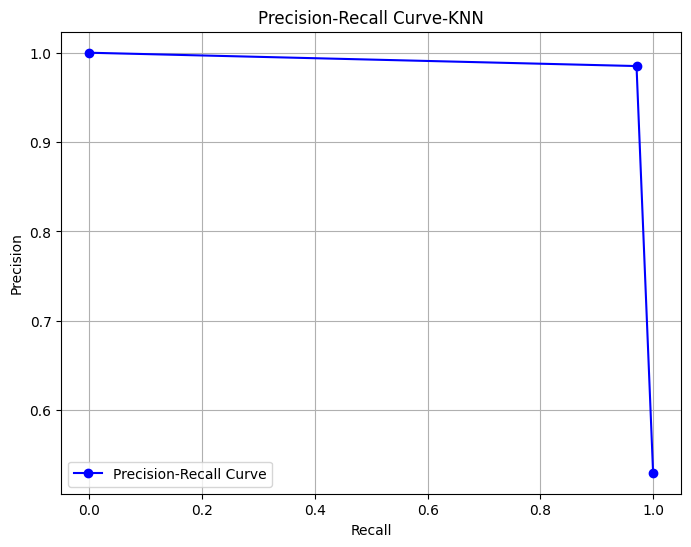

✅ Average Precision Score: 0.9717


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# 🔹 Compute Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# 🔹 Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='o', linestyle='-', color='b', label="Precision-Recall Curve")
plt.title("Precision-Recall Curve-KNN")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()

# 🔹 Calculate Average Precision Score (Optional)
avg_precision = average_precision_score(y_test, y_pred)
print(f"✅ Average Precision Score: {avg_precision:.4f}")


In [9]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, mean_squared_error

# 🔹 Use Bagging with KNN as Base Estimator (Fix: use 'estimator' instead of 'base_estimator')
bagging_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),  # ✅ Fixed
    n_estimators=50,  # Number of weak models
    random_state=42,
    bootstrap=True,  # Sampling with replacement
    n_jobs=-1  # Use all available CPU cores
)

# 🔹 Train Bagging KNN Model
bagging_knn.fit(X_train_balanced, y_train_balanced)

# 🔹 Predict on Test Set
y_pred_bagging = bagging_knn.predict(X_test)

# 🔹 Compute Evaluation Metrics
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging, average='weighted', zero_division=1)
recall_bagging = recall_score(y_test, y_pred_bagging, average='weighted')
f1_bagging = f1_score(y_test, y_pred_bagging, average='weighted')
mse_bagging = mean_squared_error(y_test, y_pred_bagging)

# 🔹 Print Results
print(f"✅ Bagging KNN Accuracy: {accuracy_bagging:.4f}")
print(f"✅ Bagging KNN Precision: {precision_bagging:.4f}")
print(f"✅ Bagging KNN Recall: {recall_bagging:.4f}")
print(f"✅ Bagging KNN F1-Score: {f1_bagging:.4f}")
print(f"✅ Bagging KNN MSE: {mse_bagging:.4f}")
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred_bagging))


✅ Bagging KNN Accuracy: 0.9844
✅ Bagging KNN Precision: 0.9844
✅ Bagging KNN Recall: 0.9844
✅ Bagging KNN F1-Score: 0.9844
✅ Bagging KNN MSE: 0.0156

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       181
           1       0.99      0.99      0.99       204

    accuracy                           0.98       385
   macro avg       0.98      0.98      0.98       385
weighted avg       0.98      0.98      0.98       385



In [10]:
from sklearn.ensemble import GradientBoostingClassifier

# 🔹 Hybrid Model: Use Gradient Boosting with KNN Features
gb_knn = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)
gb_knn.fit(X_train_balanced, y_train_balanced)

# 🔹 Predict on Test Set
y_pred_hybrid = gb_knn.predict(X_test)

# 🔹 Compute Evaluation Metrics
accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
precision_hybrid = precision_score(y_test, y_pred_hybrid, average='weighted', zero_division=1)
recall_hybrid = recall_score(y_test, y_pred_hybrid, average='weighted')
f1_hybrid = f1_score(y_test, y_pred_hybrid, average='weighted')
mse_hybrid = mean_squared_error(y_test, y_pred_hybrid)

# 🔹 Print Results
print(f"✅ Hybrid Model Accuracy: {accuracy_hybrid:.4f}")
print(f"✅ Hybrid Model Precision: {precision_hybrid:.4f}")
print(f"✅ Hybrid Model Recall: {recall_hybrid:.4f}")
print(f"✅ Hybrid Model F1-Score: {f1_hybrid:.4f}")
print(f"✅ Hybrid Model MSE: {mse_hybrid:.4f}")
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred_hybrid))


✅ Hybrid Model Accuracy: 0.9896
✅ Hybrid Model Precision: 0.9897
✅ Hybrid Model Recall: 0.9896
✅ Hybrid Model F1-Score: 0.9896
✅ Hybrid Model MSE: 0.0104

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       181
           1       0.99      1.00      0.99       204

    accuracy                           0.99       385
   macro avg       0.99      0.99      0.99       385
weighted avg       0.99      0.99      0.99       385



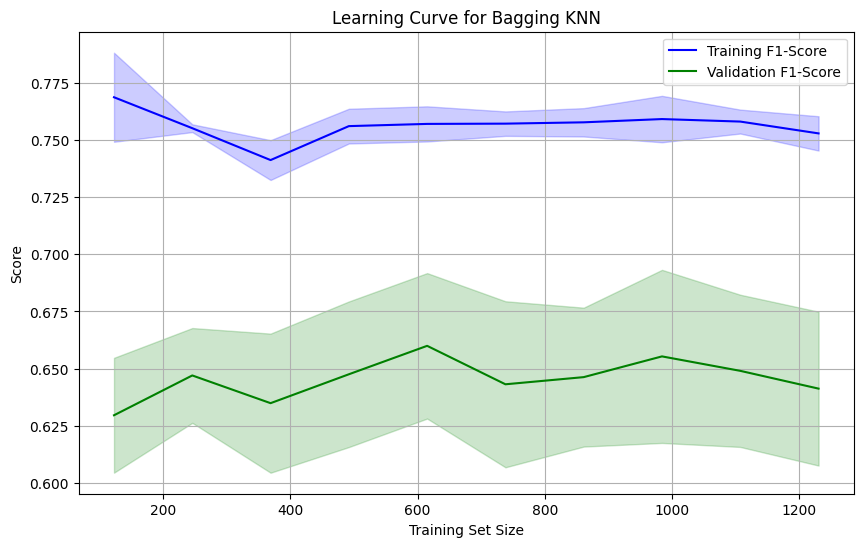

In [11]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer

# Define the scoring metric (Accuracy or F1-Score)
scorer = make_scorer(f1_score, average='weighted')

# 🔹 Generate learning curve data for Bagging KNN
train_sizes, train_scores, val_scores = learning_curve(
    bagging_knn, X_train, y_train, train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    cv=5, scoring=scorer, n_jobs=-1)

# Calculate the mean and standard deviation of training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# 🔹 Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training F1-Score', color='blue')
plt.plot(train_sizes, val_mean, label='Validation F1-Score', color='green')

# Plot the fill for standard deviation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='green')

# Labeling the graph
plt.title('Learning Curve for Bagging KNN')
plt.xlabel('Training Set Size')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

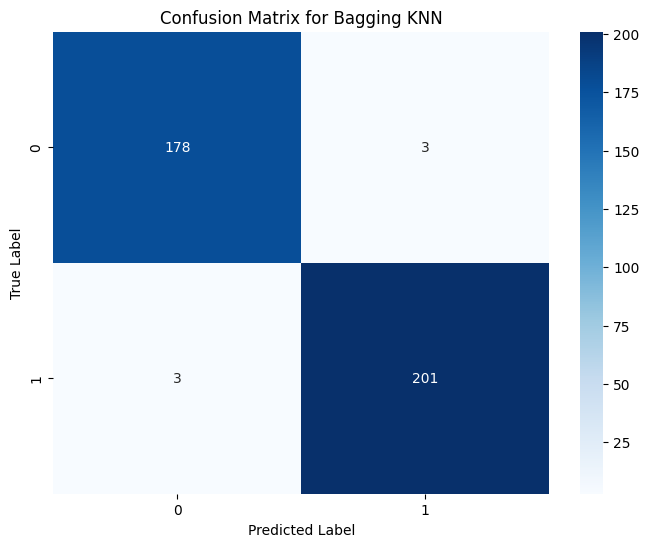

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔹 Compute the confusion matrix for Bagging KNN
cm = confusion_matrix(y_test, y_pred_bagging)

# 🔹 Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=range(len(set(y_test))), yticklabels=range(len(set(y_test))))
plt.title('Confusion Matrix for Bagging KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

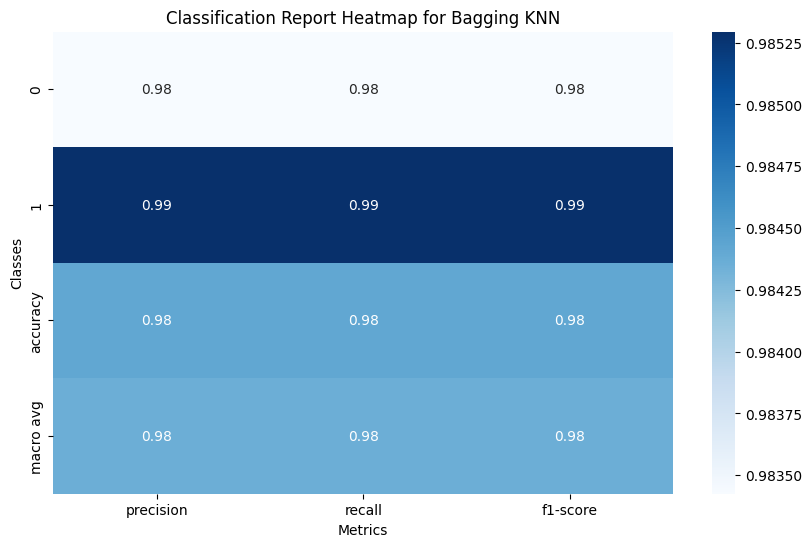

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# 🔹 Generate the classification report for Bagging KNN
report = classification_report(y_test, y_pred_bagging, output_dict=True)

# 🔹 Convert the classification report into a pandas DataFrame for easy visualization
report_df = pd.DataFrame(report).transpose()

# 🔹 Plot the heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues', fmt='.2f', annot_kws={'size': 10})
plt.title('Classification Report Heatmap for Bagging KNN')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.show()

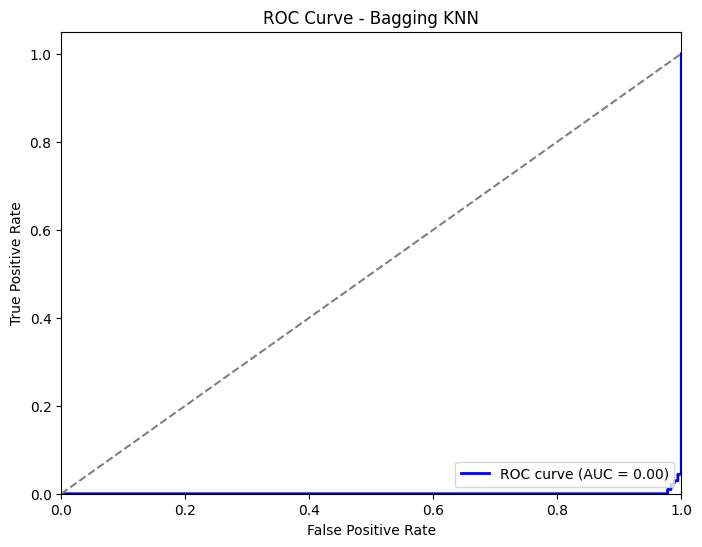

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report

# 🔹 Compute predicted probabilities for ROC curve (use probability=True in KNN)
y_pred_prob = bagging_knn.predict_proba(X_test)

# 🔹 Binarize the output labels for multiclass classification (if necessary)
y_test_bin = label_binarize(y_test, classes=[0, 1])  # Adjust the classes as per your dataset

# 🔹 Compute ROC curve for each class
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_pred_prob[:, 0])  # Adjust for multi-class, this is for class 0

# 🔹 Compute AUC score
roc_auc = auc(fpr, tpr)

# 🔹 Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Bagging KNN')
plt.legend(loc="lower right")
plt.show()


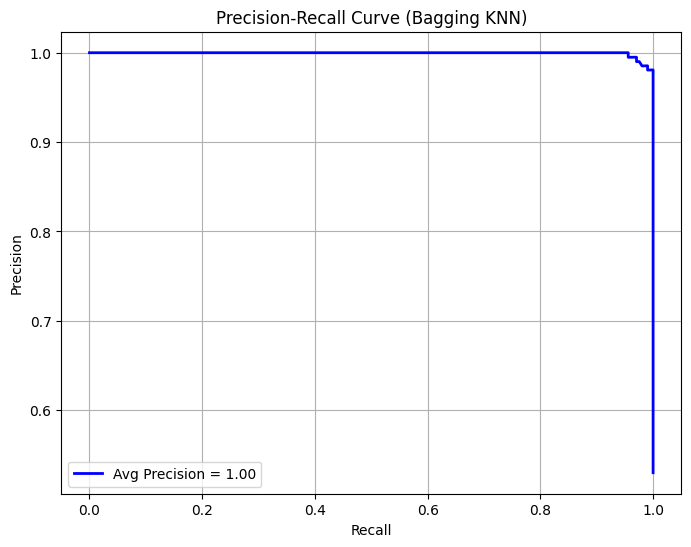

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 🔹 Get probability scores for positive class
y_scores = bagging_knn.predict_proba(X_test)

# 🔹 Binarize y_test if it's not already (adjust classes if needed)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# 🔹 Handle binary classification
if y_test_bin.shape[1] == 1:
    precision, recall, _ = precision_recall_curve(y_test, y_scores[:, 1])
    avg_precision = average_precision_score(y_test, y_scores[:, 1])

    # 🔹 Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', lw=2, label=f'Avg Precision = {avg_precision:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (Bagging KNN)')
    plt.legend()
    plt.grid(True)
    plt.show()

# 🔹 Handle multiclass classification (one-vs-rest)
else:
    plt.figure(figsize=(8, 6))
    for i in range(y_test_bin.shape[1]):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
        avg_precision = average_precision_score(y_test_bin[:, i], y_scores[:, i])
        plt.plot(recall, precision, lw=2, label=f'Class {i} (AP={avg_precision:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (Bagging KNN - Multiclass)')
    plt.legend()
    plt.grid(True)
    plt.show()


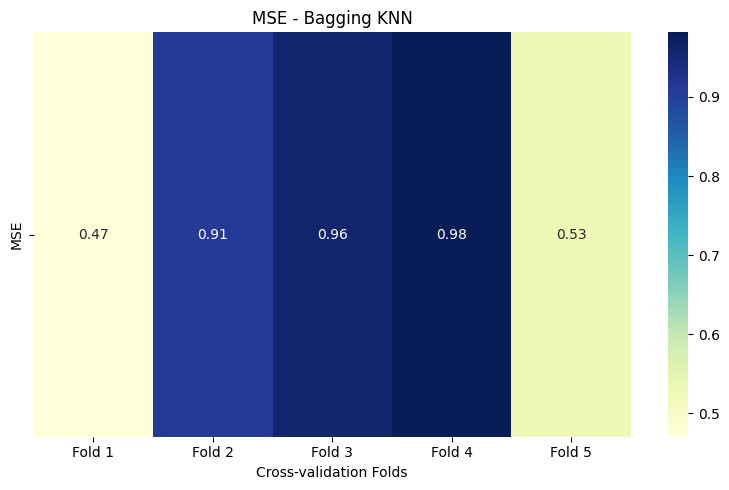

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# 🔹 Define Bagging KNN model
bagging_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=50,
    random_state=42,
    bootstrap=True,
    n_jobs=-1
)

# 🔹 Create MSE scorer
mse_scorer = make_scorer(mean_squared_error)

# 🔹 Perform cross-validation
cv_scores_bagging = cross_val_score(bagging_knn, X, y, cv=5, scoring=mse_scorer)

# 🔹 Plot MSE Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(cv_scores_bagging.reshape(1, -1), annot=True, cmap='YlGnBu', cbar=True,
            xticklabels=[f'Fold {i+1}' for i in range(len(cv_scores_bagging))],
            yticklabels=["MSE"])
plt.title('MSE - Bagging KNN')
plt.xlabel('Cross-validation Folds')
plt.tight_layout()
plt.show()
